In [91]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

In [92]:
systems_cleaned = pd.read_csv('../../data/core/systems_cleaned.csv')

In [93]:
all_data_systems = systems_cleaned[
    systems_cleaned['has_current_data']
    & systems_cleaned['has_irradiance_data']
    & systems_cleaned['has_power_data']
    & systems_cleaned['has_temperature_data']
    & systems_cleaned['has_voltage_data']
]
all_data_ids = set(all_data_systems.system_id)

In [164]:
all_data_systems.head()

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_irradiance_data,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type
0,2,Residential 1a,"Lakewood, CO",America/Denver,39.7214,-105.0972,1675.0,2.912,Dfb,12,...,True,False,True,True,True,True,True,True,multi-Si,multicrystalline_Si
1,3,Residential 1b,"Lakewood, CO",America/Denver,39.7214,-105.0972,1675.0,2.720,Dfb,12,...,True,False,True,True,True,True,True,True,amorphous si,thin_film
2,4,NREL x-Si -1,"Golden, CO",7,39.7406,-105.1774,1795.3,1.000,BSk,12,...,True,True,True,True,True,True,True,True,mono-Si,monocrystalline_Si
3,10,NREL CIS -1,"Golden, CO",7,39.7404,-105.1774,1792.8,1.120,BSk,12,...,True,True,True,True,True,True,True,True,cis family thin-film,thin_film
4,33,Silicor Materials,"Golden, CO",7,39.7404,-105.1772,1794.0,2.400,BSk,12,...,True,True,True,True,True,True,True,True,Unknown,unknown


## Parquet systems -- metadata survey.

In [94]:
metrics_dir = Path("../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

In [95]:
my_system_ids = list(all_data_ids.intersection(metrics_id_set))
my_system_ids.sort()
num_ids = len(my_system_ids)
num_ids

39

In [96]:
j = 1
system_id = my_system_ids[j]
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1385,3,353,dc_power,DC power,W,W,1.0,0.0,,avg,None,NaN,,dc_power__353
1386,3,355,dc_pos_current,DC current,A,A,1.0,0.0,,avg,None,NaN,,dc_pos_current__355
1387,3,358,das_battery_voltage,DC voltage battery,V,V,1.0,0.0,,avg,None,NaN,,das_battery_voltage__358
1388,3,352,poa_irradiance,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,None,NaN,,poa_irradiance__352
1389,3,356,module_temp_1,Temperature module,C,C,1.0,0.0,,avg,None,NaN,,module_temp_1__356
1390,3,354,dc_pos_voltage,DC voltage,V,V,1.0,0.0,,avg,None,NaN,,dc_pos_voltage__354
1391,3,357,das_temp,Temperature panel,C,C,1.0,0.0,,avg,None,NaN,,das_temp__357


In [ ]:
my_metrics = [353, 354, 355]
# grab sensor_name data of these metrics for later
relevant_rows_metrics_pruned = relevant_rows_metrics.loc[
    relevant_rows_metrics.loc[:, 'metric_id'].isin(my_metrics) #keep only rows whose metric_id is in my_metrics
]
# to keep the same sorting, re-name metric id's as follows.
metric_ids = tuple(relevant_rows_metrics_pruned.metric_id)
metric_names = tuple(relevant_rows_metrics_pruned.sensor_name)

In [112]:
access_system_dir = Path(f'../../../data_ds_project/systems/parquet/{system_id}/')
current_pq = pq.ParquetDataset(access_system_dir,
                               filters= [
                                   ('metric_id', 'in', my_metrics) #in particular, only look a the my_metric_id's
                               ])
current_df = current_pq.read().to_pandas()

In [113]:
current_df

,measured_on,utc_measured_on,metric_id,value
0,2010-01-21 11:02:00,NaT,355,2.3000
1,2010-01-21 11:03:00,NaT,353,790.2000
2,2010-01-21 11:04:00,NaT,355,2.4060
3,2010-01-21 11:05:00,NaT,354,330.8000
4,2010-01-21 11:06:00,NaT,353,744.2000
...,...,...,...,...
5512398,2017-01-30 16:30:00,NaT,353,-7999.0000
5512399,2017-01-30 16:35:00,NaT,353,-7999.0000
5512400,2017-01-30 16:40:00,NaT,355,-7999.0000
5512401,2017-01-30 16:45:00,NaT,355,-7999.0000


In [114]:
# to make calculations, 'widen' the frame!
# but drop duplicates to make this possible.
current_df = current_df.drop_duplicates()
current_df_wide = current_df.pivot(
    index = 'measured_on', 
    columns = 'metric_id',
    values = 'value'
)
current_df_wide.head()

metric_id,353,354,355
measured_on,,,
2010-01-21 11:02:00,764.8,332.6,2.300
2010-01-21 11:03:00,790.2,335.8,2.353
2010-01-21 11:04:00,797.5,331.5,2.406
2010-01-21 11:05:00,778.8,330.8,2.354
2010-01-21 11:06:00,744.2,326.9,2.276


In [102]:
metric_names

('dc_power', 'dc_pos_current', 'dc_pos_voltage')

In [115]:
metric_ids

(353, 355, 354)

In [116]:
changeup_dict = {
    metric_ids[j]: metric_names[j] for j in range(len(my_metrics))
}
current_df_wide = current_df_wide.rename(
    columns=changeup_dict
)

In [117]:
current_df_wide.head()

metric_id,dc_power,dc_pos_voltage,dc_pos_current
measured_on,,,
2010-01-21 11:02:00,764.8,332.6,2.300
2010-01-21 11:03:00,790.2,335.8,2.353
2010-01-21 11:04:00,797.5,331.5,2.406
2010-01-21 11:05:00,778.8,330.8,2.354
2010-01-21 11:06:00,744.2,326.9,2.276


In [118]:
current_df_wide['power_manual'] = current_df_wide['dc_pos_current'] * current_df_wide['dc_pos_voltage']

In [154]:
current_df_wide.describe()

metric_id,dc_power,dc_pos_voltage,dc_pos_current,power_manual,abs_power_diff
count,1.837468e+06,1.837468e+06,1.837467e+06,1.837467e+06,1.837467e+06
mean,-5.861112e+01,-2.894770e+02,-4.539986e+02,-7.365140e+04,7.520908e+04
std,2.070829e+03,1.858674e+03,1.853499e+03,4.686341e+05,4.671236e+05
min,-7.999000e+03,-7.999000e+03,-7.999000e+03,-3.714740e+06,0.000000e+00
25%,0.000000e+00,-4.820000e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.300000e-02,6.596000e+01,3.000000e-04,0.000000e+00,2.585512e-02
75%,4.807000e+02,3.096000e+02,1.543000e+00,5.305619e+02,2.012000e-01
max,9.168922e+03,4.763000e+02,5.345000e+01,6.398400e+07,6.399200e+07


Wait -- what's with the -7999 for power, voltage, current?

In [166]:
current_df_wide[['dc_power', 'dc_pos_current']].value_counts()

dc_power    dc_pos_current
 0.0000      0.0000           537736
-7999.0000  -7999.0000        104577
-0.0010      0.0000            54861
-0.0003      0.0003            23749
 0.0010      0.0000            20992
                               ...  
-7999.0000   2.2790                1
             2.2210                1
             2.1670                1
             2.1170                1
             2.1070                1
Name: count, Length: 625357, dtype: int64

In [167]:
current_df_wide['dc_pos_voltage'].value_counts()

dc_pos_voltage
-7999.0000    100333
 309.9000       5223
 310.1000       5164
 310.2000       5156
 310.0000       5149
               ...  
 304.8934          1
 310.1844          1
 305.3768          1
 306.1602          1
 309.3875          1
Name: count, Length: 182526, dtype: int64

### Working assumption: These -7999's are a default bad-data value.

Fortunately, for exploring P = IV, I want positive values anyway.

In [168]:
# trim zero values before graphing
current_df_trimmed = current_df_wide[
    (current_df_wide['dc_power'] > 0.5)
    & (current_df_wide['dc_pos_current'] > 0.5)
    & (current_df_wide['dc_pos_voltage'] > 0.5)
]

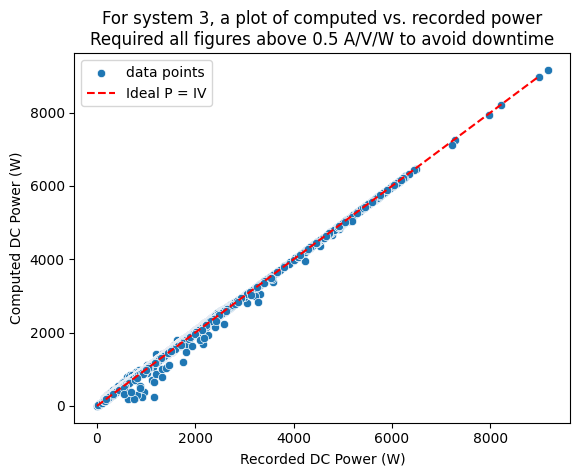

In [169]:
sns.scatterplot(
    data= current_df_trimmed,
    x = 'dc_power',
    y = 'power_manual',
    label = 'data points'
)
plt.title(f'For system {system_id}, a plot of computed vs. recorded power\n'
          + 'Required all figures above 0.5 A/V/W to avoid downtime')
plt.plot([0, 9000], [0, 9000], '--r', label = 'Ideal P = IV')
plt.xlabel('Recorded DC Power (W)')
plt.ylabel('Computed DC Power (W)')
plt.legend()
plt.show()

Clearly, $P = IV$ is not as ignored as in the other case, but recorded power tends to be larger.

In [ ]:
current_df_wide['abs_power_diff'] = np.abs(current_df_wide['dc_power'] - current_df_wide['power_manual'])
# remake trimmed version
current_df_trimmed = current_df_wide[
    (current_df_wide['dc_power'] > 0.5)
    & (current_df_wide['dc_pos_current'] > 0.5)
    & (current_df_wide['dc_pos_voltage'] > 0.5)
]

In [175]:
current_df_trimmed.describe()

metric_id,dc_power,dc_pos_voltage,dc_pos_current,power_manual,abs_power_diff
count,609869.000000,609869.000000,609869.000000,609869.000000,609869.000000
mean,1174.301632,310.243712,3.788406,1175.464805,1.486475
std,727.807214,17.557981,2.491360,728.987365,6.173865
min,10.060000,4.961000,0.500100,4.449861,0.000000
25%,486.600000,307.600000,1.560000,486.564000,0.066100
50%,1092.000000,310.900000,3.463000,1092.156771,0.175300
75%,1867.000000,316.500000,5.995000,1869.709727,0.486600
max,9168.922000,443.100000,53.450000,9164.142888,921.822891


So in 75% of cases, we are less than 0.5 W off!  Not bad!

We say 0.5 KW (500 W) is a significant difference

In [172]:
current_df_trimmed_sig_diff = current_df_trimmed[current_df_trimmed['abs_power_diff'] >= 500]

In [173]:
current_df_trimmed_sig_diff.describe()

metric_id,dc_power,dc_pos_voltage,dc_pos_current,power_manual,abs_power_diff
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,1101.381925,118.578493,4.590591,485.407305,615.974620
std,329.560198,25.828723,4.305910,361.753141,131.419075
min,752.337600,86.359120,1.638302,178.819924,505.656073
25%,878.657075,101.827555,1.824583,235.481304,553.344824
50%,1061.450550,108.746550,2.276381,313.956412,573.381845
75%,1206.309500,146.592350,6.291940,682.119396,605.289479
max,1752.400000,150.716500,13.865970,1197.452967,921.822891


In [174]:
current_df_trimmed_sig_diff.shape

(8, 5)

OK, so unlike the previous case, there are only a few giant issues.